# 💰 Phân tích Giá Vàng Realtime
> So sánh giá mua/bán giữa SJC, PNJ, DOJI, BTMC

**Mục tiêu**: Tìm nơi mua/bán vàng có lợi nhất, phân tích spread (chênh lệch mua-bán).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True

prices = pd.read_csv('../data/prices.csv')
prices['buy_price_M'] = prices['buy_price'] / 1e6
prices['sell_price_M'] = prices['sell_price'] / 1e6
prices['spread_M'] = prices['sell_price_M'] - prices['buy_price_M']
prices['spread_pct'] = prices['spread_M'] / prices['buy_price_M'] * 100

print(f'Price records: {len(prices)}')
print(f'Sources: {prices["source_name"].unique()}')
prices.head()

Price records: 42
Sources: <StringArray>
['PNJ', 'DOJI', 'BTMC', 'SJC']
Length: 4, dtype: str


,id,shop_id,source_name,gold_type,buy_price,sell_price,unit,crawled_at,buy_M,sell_M,spread_M,spread_pct,buy_price_M,sell_price_M
0,1,NaN,PNJ,Vàng SJC,85500000.0,87500000.0,lượng,2026-03-14 05:14:14,85.5,87.5,2.0,2.339181,85.5,87.5
1,2,NaN,PNJ,Vàng PNJ 999.9,84200000.0,85700000.0,lượng,2026-03-14 05:14:14,84.2,85.7,1.5,1.781473,84.2,85.7
2,3,NaN,PNJ,Vàng tây 18K,45000000.0,47000000.0,lượng,2026-03-14 05:14:14,45.0,47.0,2.0,4.444444,45.0,47.0
3,4,NaN,DOJI,Vàng miếng SJC,85500000.0,87500000.0,lượng,2026-03-14 05:14:14,85.5,87.5,2.0,2.339181,85.5,87.5
4,5,NaN,DOJI,Vàng nhẫn DOJI 999.9,84100000.0,85700000.0,lượng,2026-03-14 05:14:14,84.1,85.7,1.6,1.902497,84.1,85.7


## 1. So sánh giá bán theo nguồn

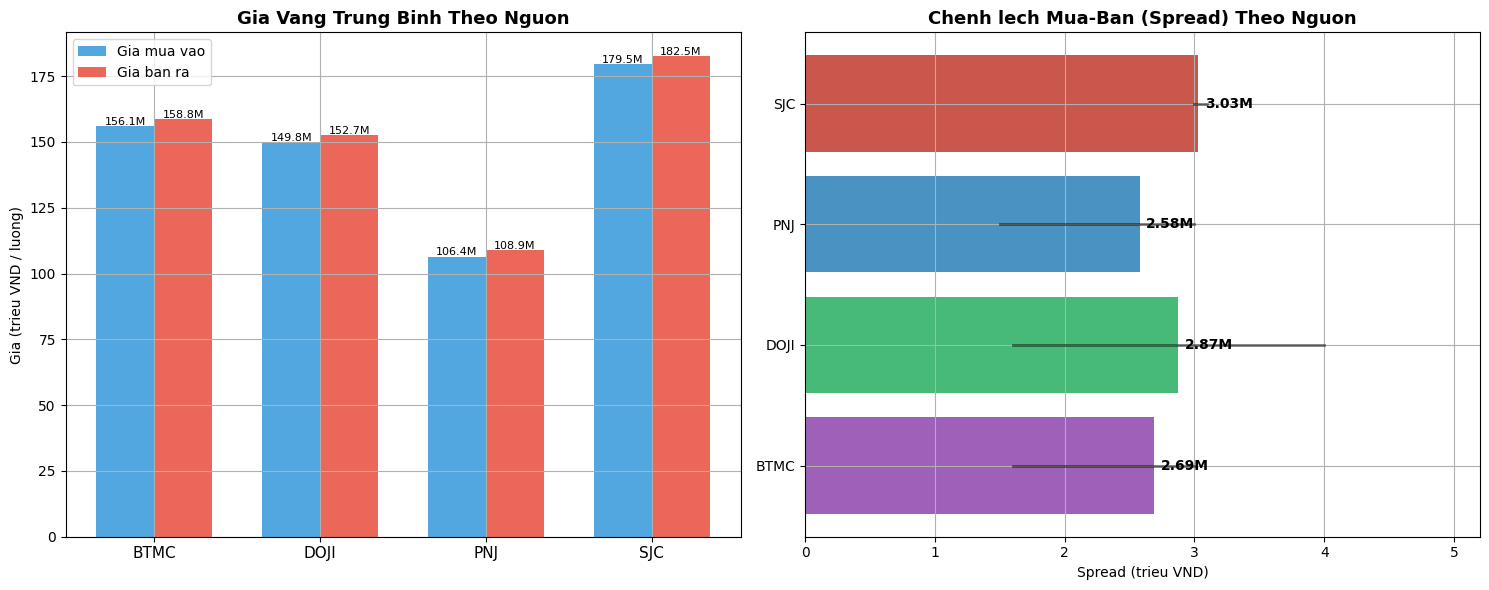


=== SPREAD ANALYSIS ===
                 mean  min  max
source_name                    
BTMC         2.687500  1.6  3.0
DOJI         2.872727  1.6  4.0
PNJ          2.576923  1.5  3.0
SJC          3.030000  3.0  3.1


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

source_colors = {'SJC': '#C0392B', 'PNJ': '#2980B9', 'DOJI': '#27AE60', 'BTMC': '#8E44AD'}

# Buy vs Sell by source
source_avg = prices.groupby('source_name')[['buy_price_M', 'sell_price_M']].mean()
x = range(len(source_avg))
w = 0.35
axes[0].bar([i - w/2 for i in x], source_avg['buy_price_M'], w,
            label='Gia mua vao', color='#3498DB', alpha=0.85)
axes[0].bar([i + w/2 for i in x], source_avg['sell_price_M'], w,
            label='Gia ban ra', color='#E74C3C', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(source_avg.index, fontsize=11)
axes[0].set_ylabel('Gia (trieu VND / luong)')
axes[0].set_title('Gia Vang Trung Binh Theo Nguon', fontsize=13, fontweight='bold')
axes[0].legend()
for i, (src, row) in enumerate(source_avg.iterrows()):
    axes[0].text(i - w/2, row['buy_price_M'] + 0.5, f'{row["buy_price_M"]:.1f}M', 
                ha='center', fontsize=8)
    axes[0].text(i + w/2, row['sell_price_M'] + 0.5, f'{row["sell_price_M"]:.1f}M',
                ha='center', fontsize=8)

# Spread analysis
spread_by_source = prices.groupby('source_name')['spread_M'].agg(['mean', 'min', 'max'])
axes[1].barh(spread_by_source.index, spread_by_source['mean'],
             color=[source_colors.get(s, 'gray') for s in spread_by_source.index],
             alpha=0.85)
# Error bars
for i, (src, row) in enumerate(spread_by_source.iterrows()):
    axes[1].plot([row['min'], row['max']], [i, i], 'k-', linewidth=2, alpha=0.5)
    axes[1].text(row['mean'] + 0.05, i, f'{row["mean"]:.2f}M', va='center', fontweight='bold')
axes[1].set_xlabel('Spread (trieu VND)')
axes[1].set_title('Chenh lech Mua-Ban (Spread) Theo Nguon', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, spread_by_source['max'].max() * 1.3)

plt.tight_layout()
plt.savefig('../data/price_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n=== SPREAD ANALYSIS ===')
print(spread_by_source)

## 2. Chi tiết từng loại vàng

In [3]:
print('=== GIA VANG HIEN TAI ===')
print(f'{"Nguon":8} {"Loai vang":35} {"Mua vao":>12} {"Ban ra":>12} {"Spread":>10} {"Spread%":>8}')
print('-' * 90)
for _, row in prices.sort_values(['source_name', 'sell_price_M'], ascending=[True, False]).iterrows():
    spread = row['spread_M'] if pd.notna(row['spread_M']) else 0
    spread_p = row['spread_pct'] if pd.notna(row['spread_pct']) else 0
    buy = f'{row["buy_price_M"]:.3f}M' if pd.notna(row['buy_price_M']) else 'N/A'
    sell = f'{row["sell_price_M"]:.3f}M' if pd.notna(row['sell_price_M']) else 'N/A'
    print(f'{row["source_name"]:8} {row["gold_type"][:35]:35} {buy:>12} {sell:>12} {spread:>9.3f}M {spread_p:>7.2f}%')

print('\n=== KHUYEN NGHI ===')
best_buy = prices.loc[prices['buy_price_M'].idxmax()]
best_spread = prices.loc[prices['spread_M'].idxmin()]
print(f'Noi ban vang gia cao nhat: {best_buy["source_name"]} - {best_buy["gold_type"]}')
print(f'  Gia mua vao: {best_buy["buy_price_M"]:.3f}M VND/luong')
print(f'Spread thap nhat (it mat phi nhat): {best_spread["source_name"]} - {best_spread["gold_type"]}')
print(f'  Spread: {best_spread["spread_M"]:.3f}M VND')

=== GIA VANG HIEN TAI ===
Nguon    Loai vang                                Mua vao       Ban ra     Spread  Spread%
------------------------------------------------------------------------------------------
BTMC     Vàng BTMC 9999 miếng                    180.000M     183.000M     3.000M    1.67%
BTMC     Nhẫn BTMC 9999                          180.000M     183.000M     3.000M    1.67%
BTMC     Vàng BTMC 9999 miếng                    180.000M     183.000M     3.000M    1.67%
BTMC     Nhẫn BTMC 9999                          180.000M     183.000M     3.000M    1.67%
BTMC     Vàng SJC tại BTMC                       179.600M     182.600M     3.000M    1.67%
BTMC     Vàng SJC tại BTMC                       179.600M     182.600M     3.000M    1.67%
BTMC     Vàng SJC 99.99                           85.500M      87.400M     1.900M    2.22%
BTMC     Vàng BTMC 9999                           84.000M      85.600M     1.600M    1.90%
DOJI     Vàng miếng DOJI HCM                     179.600M     18

## 3. Market Intelligence — Business Insights

In [4]:
shops = pd.read_csv('../data/shops.csv')

print('=== BUSINESS INTELLIGENCE REPORT ===')
print('=== Thi truong vang Da Nang ===\n')

# Market size
print(f'1. QUY MO THI TRUONG')
print(f'   - Tong tiem vang: {len(shops)} tiem')
print(f'   - Mat do: ~{len(shops)/8:.0f} tiem/quan (binh quan 8 quan)')
print(f'   - Gia vang SJC hien tai: ~{prices[prices["source_name"]=="SJC"]["sell_price_M"].mean():.1f}M VND/luong')

print(f'\n2. PHAN KHUC GIA')
for src in ['SJC', 'PNJ', 'DOJI', 'BTMC']:
    src_prices = prices[prices['source_name'] == src]
    if len(src_prices) > 0:
        avg_sell = src_prices['sell_price_M'].mean()
        avg_spread = src_prices['spread_M'].mean()
        print(f'   {src}: ban ~{avg_sell:.1f}M/luong | spread ~{avg_spread:.2f}M ({avg_spread/avg_sell*100:.1f}%)')

print(f'\n3. CO HOI THI TRUONG')
shops_rated = shops[shops['rating'] > 0]
underserved = shops[shops['district'].isin(shops['district'].value_counts().tail(3).index)]
low_rated_areas = shops_rated.groupby('district')['rating'].mean().sort_values().head(3)
print(f'   Quan it tiem vang (co the thieu cung):')
for d, c in shops['district'].value_counts().tail(3).items():
    print(f'     - {d}: {c} tiem')
print(f'   Quan chat luong dich vu thap (co the cai thien):')
for d, r in low_rated_areas.items():
    print(f'     - {d}: rating TB = {r:.2f}')

print(f'\n4. LEADERS BY DISTRICT')
for district in shops['district'].value_counts().head(5).index:
    top = shops_rated[shops_rated['district'] == district].nlargest(1, 'rating')
    if len(top) > 0:
        row = top.iloc[0]
        print(f'   {district}: #{row["name"][:35]} (rating {row["rating"]})')

=== BUSINESS INTELLIGENCE REPORT ===
=== Thi truong vang Da Nang ===

1. QUY MO THI TRUONG
   - Tong tiem vang: 150 tiem
   - Mat do: ~19 tiem/quan (binh quan 8 quan)
   - Gia vang SJC hien tai: ~182.5M VND/luong

2. PHAN KHUC GIA
   SJC: ban ~182.5M/luong | spread ~3.03M (1.7%)
   PNJ: ban ~108.9M/luong | spread ~2.58M (2.4%)
   DOJI: ban ~152.7M/luong | spread ~2.87M (1.9%)
   BTMC: ban ~158.8M/luong | spread ~2.69M (1.7%)

3. CO HOI THI TRUONG
   Quan it tiem vang (co the thieu cung):
     - Đà Nẵng: 1 tiem
     - Hòa Vang: 1 tiem
     - Liên Chiểu: 1 tiem
   Quan chat luong dich vu thap (co the cai thien):
     - Cẩm Lệ: rating TB = 4.17
     - Liên Chiểu: rating TB = 4.20
     - Thanh Khê: rating TB = 4.23

4. LEADERS BY DISTRICT
   Hải Châu: #Tiệm Vàng Kim Long (rating 5.0)
   Thanh Khê: #Cửa hàng Trang sức PNJ tại Go! Đà N (rating 5.0)
   Sơn Trà: #Hiệu vàng Ngọc Nhung (rating 5.0)
   Cẩm Lệ: #CÔNG TY TNHH GOLDEN PASTRY BÁNH VÀN (rating 5.0)
   Ngũ Hành Sơn: #Hiệu Vàng Bạc Ngọc 